## Reliability & DNFs in Formula 1 (1950–2025)

This notebook focuses on **race reliability** in Formula 1 by analyzing **non-finishes (DNFs)** across all seasons from 1950 to 2025.

Unlike dominance metrics (wins concentration), reliability analysis helps answer a different set of questions:
**How often did cars fail to reach the finish line, how has this changed over time, and what were the most common reasons for retirements?**

### Questions addressed in this notebook

- How has the **DNF rate per season** evolved from 1950 to 2025?
- What are the most common **DNF reasons** across the entire history of Formula 1?
- How do the dominant DNF reasons differ across historical eras (e.g., 1950s vs modern F1)?

### Notes on definitions

In this analysis, we distinguish between:
- **Finished / Classified entries** (including results such as `Finished` and `+1 Lap`, `+2 Laps`, etc.)
- **DNF entries**, where the car did not finish due to accidents, mechanical failures, or other retirement reasons.

This definition is based on the official status codes available in the dataset and is designed to produce a consistent, comparable reliability metric across eras.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.data_overview import overview_dataframe

results = load_data('results')
races = load_data('races')
status = load_data('status')
constructors = load_data('constructors')

In [27]:
overview = overview_dataframe('Status', status)


 STATUS
--------------------------------------------------
Shape: (139, 2)
Columns: ['statusId', 'status']
DTypes:
 statusId    int64
status        str
dtype: object
Missing values:
 statusId    0
status      0
dtype: int64
Duplicated rows: 0
First 2 rows:
    statusId        status
0         1      Finished
1         2  Disqualified



### About the `status` DataFrame

The `status` table provides detailed information on the classification outcome of each race entry.
While the general intuition is that **"Finished" means finished and everything else means not finished**, this distinction requires careful handling due to several important nuances.

In particular, statuses such as `+1 Lap`, `+2 Laps`, and similar indicate that a car was **classified** at the finish, despite being lapped. These entries should **not** be treated as DNFs.

To ensure a consistent and historically comparable definition, race outcomes are grouped into three categories:

#### 1. Finished / Classified (Not DNF)
Entries that were officially classified at the finish, including:
- `Finished`
- All lapped classifications (e.g. `+1 Lap`, `+2 Laps`, etc.)

This group corresponds to status IDs:
1, 11–19, 45, 50, 53, 55, 58, 111–120, 122–125, 128, 133, 134


#### 2. DNF (Did Not Finish)
Entries where the car failed to reach the finish line due to:
- Mechanical failures
- Accidents or collisions
- Other retirement-related reasons

All status IDs **not included** in Group 1 or Group 3 are classified as DNF.

#### 3. Not Finished but Not DNF
Entries where the car did not finish the race but was not classified as a DNF, such as:
- Disqualifications
- Did not start
- Injury or illness-related withdrawals

This group includes status IDs:
81, 82 (Injury), 90, 97, 139 (Illness)



This three-level classification allows DNFs to be analyzed both as a general indicator of race completion stability and, separately, by underlying causes in subsequent analyses.


In [29]:
df = (
    results
    .merge(status, on='statusId', how='left')
)


In [30]:
all_status_ids = status['statusId'].unique()

groups = {
    'Finished': [1, 11, 12, 13, 14, 15, 16, 17, 18, 19, 45, 50,
                 53, 55, 58, 88, 111, 112, 113, 114, 115, 116, 117,
                 118, 119, 120, 122, 123, 124, 125, 127, 128, 133, 134],
    'NotFinishedNotDNF': [28, 68, 73, 81, 82, 90, 93, 97, 100, 107, 136, 139]
}

groups['DNF'] = [
    i for i in all_status_ids
    if i not in groups['Finished'] and i not in groups['NotFinishedNotDNF']
]

In [31]:
status_mapping = {}
for group_name, ids in groups.items():
    for s_id in ids:
        status_mapping[s_id] = group_name

results['statusGroup'] = results['statusId'].map(status_mapping)

results[['statusId', 'statusGroup']]

,statusId,statusGroup
0,1,Finished
1,1,Finished
2,1,Finished
3,1,Finished
4,1,Finished
...,...,...
27233,1,Finished
27234,11,Finished
27235,11,Finished
27236,11,Finished


In [41]:
finishing_status_by_year = (
    results
    .merge(races[['raceId', 'year']], on='raceId', how='left')
    .groupby(['year', 'statusGroup'])
    .size()
    .reset_index(name='count')
)

finishing_status_by_year['entries'] = finishing_status_by_year.groupby(['year'])['count'].transform('sum')
finishing_status_by_year['percent'] = ((finishing_status_by_year['count'] / finishing_status_by_year['entries']) * 100).round(2)
finishing_status_by_year

,year,statusGroup,count,entries,percent
0,1950,DNF,80,160,50.00
1,1950,Finished,80,160,50.00
2,1951,DNF,89,179,49.72
3,1951,Finished,90,179,50.28
4,1952,DNF,89,215,41.40
...,...,...,...,...,...
206,2023,NotFinishedNotDNF,1,440,0.23
207,2024,DNF,54,479,11.27
208,2024,Finished,425,479,88.73
209,2025,DNF,60,479,12.53


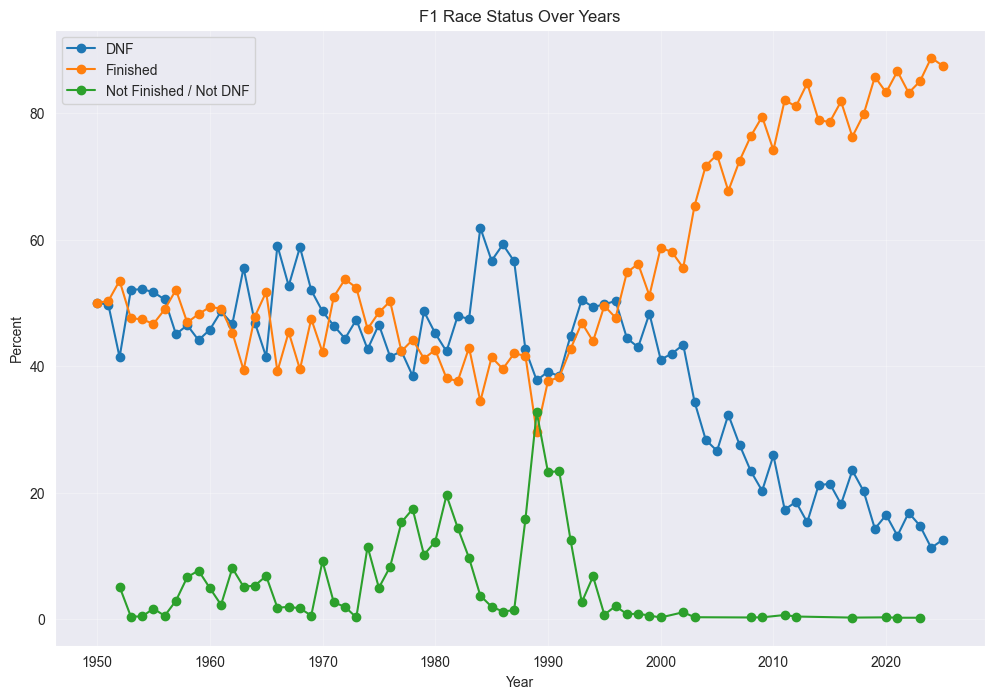

In [34]:
plt.figure(figsize=(12, 8))

# 1. Plot DNF
dnf_data = finishing_status_by_year[finishing_status_by_year['statusGroup'] == 'DNF']
plt.plot(dnf_data['year'], dnf_data['percent'], label='DNF', marker='o')

# 2. Plot Finished
finished_data = finishing_status_by_year[finishing_status_by_year['statusGroup'] == 'Finished']
plt.plot(finished_data['year'], finished_data['percent'], label='Finished', marker='o')

# 3. Plot NotFinishedNotDNF (Check the name carefully!)
not_fin_data = finishing_status_by_year[finishing_status_by_year['statusGroup'] == 'NotFinishedNotDNF']
plt.plot(not_fin_data['year'], not_fin_data['percent'], label='Not Finished / Not DNF', marker='o')

plt.title('F1 Race Status Over Years')
plt.xlabel('Year')
plt.ylabel('Percent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### DNF Rate by Season

In this section, we analyzed the share of race entries that did not finish (DNF) for each Formula 1 season from 1950 to 2025.

Each race result was classified into one of three categories:
- **Finished / Classified** (including lapped finishes such as `+1 Lap` etc)
- **DNF**, where the car retired due to mechanical failures, accidents, or similar reasons
- **Not Finished but Not DNF** (e.g. disqualifications or did not start)

The analysis shows a clear historical trend:
- Early Formula 1 seasons were characterized by extremely high DNF rates, often exceeding 50%.
- The 1980s display a noticeable increase in retirements, corresponding to the turbo era and higher mechanical stress.
- From the late 1990s onward, DNF rates decline sharply, reaching historically low levels in modern Formula 1.

This trend highlights the dramatic improvement in car reliability over time and provides important context for interpreting performance and championship outcomes across different eras.


## Main Causes of Race Retirements (DNFs)


In [35]:
dnf_table = results[results['statusGroup'] == 'DNF']
dnf_table = (
    dnf_table
    .merge(status, on='statusId', how='left')
)
dnf_table[['resultId', 'raceId', 'driverId', 'constructorId', 'statusId', 'statusGroup', 'status']]

,resultId,raceId,driverId,constructorId,statusId,statusGroup,status
0,7,18,7,5,5,DNF,Engine
1,8,18,8,6,5,DNF,Engine
2,9,18,9,2,4,DNF,Collision
3,10,18,10,7,3,DNF,Accident
4,11,18,11,8,7,DNF,Transmission
...,...,...,...,...,...,...,...
10228,27203,1166,857,1,2,DNF,Disqualified
10229,27220,1167,840,117,130,DNF,Collision damage
10230,27221,1167,865,215,29,DNF,Puncture
10231,27222,1167,860,210,6,DNF,Gearbox


In [36]:
dnf_table.status.value_counts()

status
Engine            2032
Accident          1074
Collision          865
Gearbox            813
Spun off           795
                  ... 
CV joint             1
Engine misfire       1
Brake duct           1
Debris               1
Cooling system       1
Name: count, Length: 93, dtype: int64

#### We have 102 reasons of DNF. We split it on 7 groups: Mechanical Failure, Accident / Collision, Car Damage(Non-mechanical), Driver Error, Regulations(Technical Disqualification), Strategic / Race and Other

In [37]:
all_dnfs = dnf_table.status.unique()

from config.dnf_groups import DNF_GROUPS

DNF_GROUPS ['Other'] = [
    i for i in all_dnfs
    if i not in DNF_GROUPS ['Regulations / Technical']
       and i not in DNF_GROUPS ['Mechanical Failure']
       and i not in DNF_GROUPS ['Accident / Collision']
       and i not in DNF_GROUPS ['Car Damage']
       and i not in DNF_GROUPS ['Strategic / Race']
]

In [40]:
dnf_mapping ={}
for group_name, ids in DNF_GROUPS.items():
    for s_id in ids:
        dnf_mapping[s_id] = group_name

dnf_table['dnfStatus'] = dnf_table['status'].map(dnf_mapping)
dnf_table

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,statusGroup,status,dnfStatus
0,7,18,7,5,14,17,7,7,7,2.0,...,\N,\N,54,8,1:29.534,213.224,5,DNF,Engine,Mechanical Failure
1,8,18,8,6,1,15,8,8,8,1.0,...,\N,\N,20,4,1:27.903,217.18,5,DNF,Engine,Mechanical Failure
2,9,18,9,2,4,2,\N,R,9,0.0,...,\N,\N,15,9,1:28.753,215.1,4,DNF,Collision,Accident / Collision
3,10,18,10,7,12,18,\N,R,10,0.0,...,\N,\N,23,13,1:29.558,213.166,3,DNF,Accident,Accident / Collision
4,11,18,11,8,18,19,\N,R,11,0.0,...,\N,\N,24,15,1:30.892,210.038,7,DNF,Transmission,Mechanical Failure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10228,27203,1166,857,1,81,5,20,D,20,0.0,...,\N,\N,\N,\N,\N,\N,2,DNF,Disqualified,Regulations / Technical
10229,27220,1167,840,117,18,\N,17,17,17,0.0,...,\N,\N,51,4,1:23.484,\N,130,DNF,Collision damage,Accident / Collision
10230,27221,1167,865,215,6,\N,18,18,18,0.0,...,\N,\N,52,12,1:24.317,\N,29,DNF,Puncture,Car Damage
10231,27222,1167,860,210,87,\N,19,R,19,0.0,...,\N,\N,34,15,1:24.930,\N,6,DNF,Gearbox,Mechanical Failure


In [46]:
dnf_status_by_year = (
    dnf_table
    .merge(races[['raceId', 'year']], on='raceId', how='left')
    .groupby(['year', 'dnfStatus'])
    .size()
    .reset_index(name='count')
)
dnf_status_by_year['all_dnf'] = dnf_status_by_year.groupby('year')['count'].transform('sum')
dnf_status_by_year['percent'] = ((dnf_status_by_year['count'] / dnf_status_by_year['all_dnf']) * 100).round(2)
dnf_status_by_year

,year,dnfStatus,count,all_dnf,percent
0,1950,Accident / Collision,15,80,18.75
1,1950,Mechanical Failure,59,80,73.75
2,1950,Regulations / Technical,1,80,1.25
3,1950,Strategic / Race,5,80,6.25
4,1951,Accident / Collision,10,89,11.24
...,...,...,...,...,...
349,2024,Strategic / Race,11,54,20.37
350,2025,Accident / Collision,34,60,56.67
351,2025,Car Damage,2,60,3.33
352,2025,Mechanical Failure,18,60,30.00


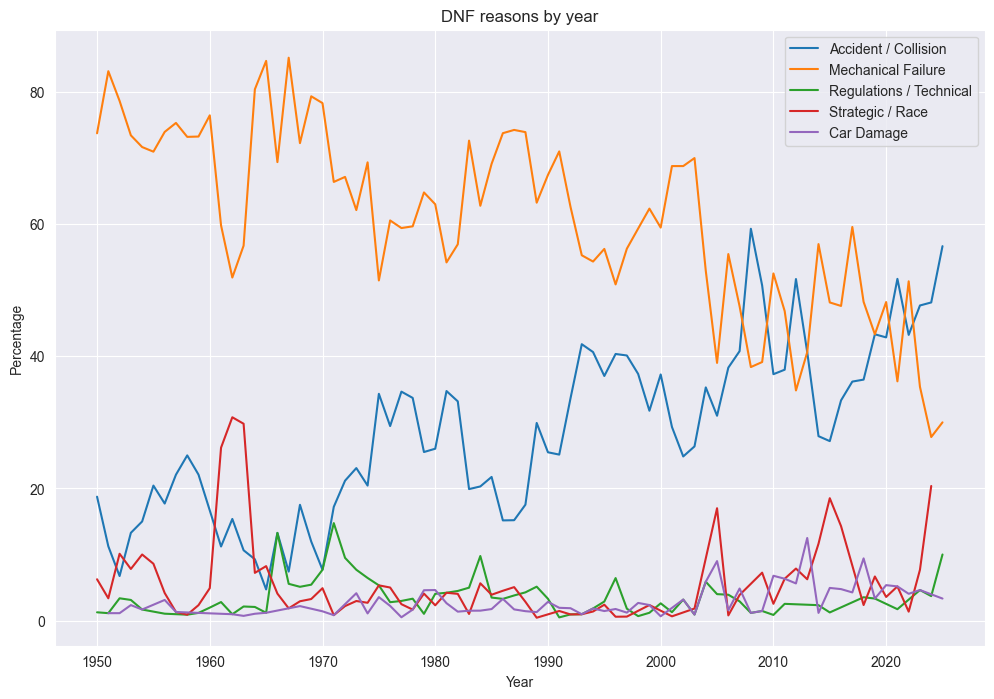

In [51]:
plt.figure(figsize=(12, 8))
for status in dnf_status_by_year['dnfStatus'].unique():
    sub = dnf_status_by_year[dnf_status_by_year['dnfStatus'] == status].sort_values('year')
    plt.plot(
        sub['year'],
        sub['percent'],
        label=status,
    )

plt.title("DNF reasons by year")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend()
plt.show()

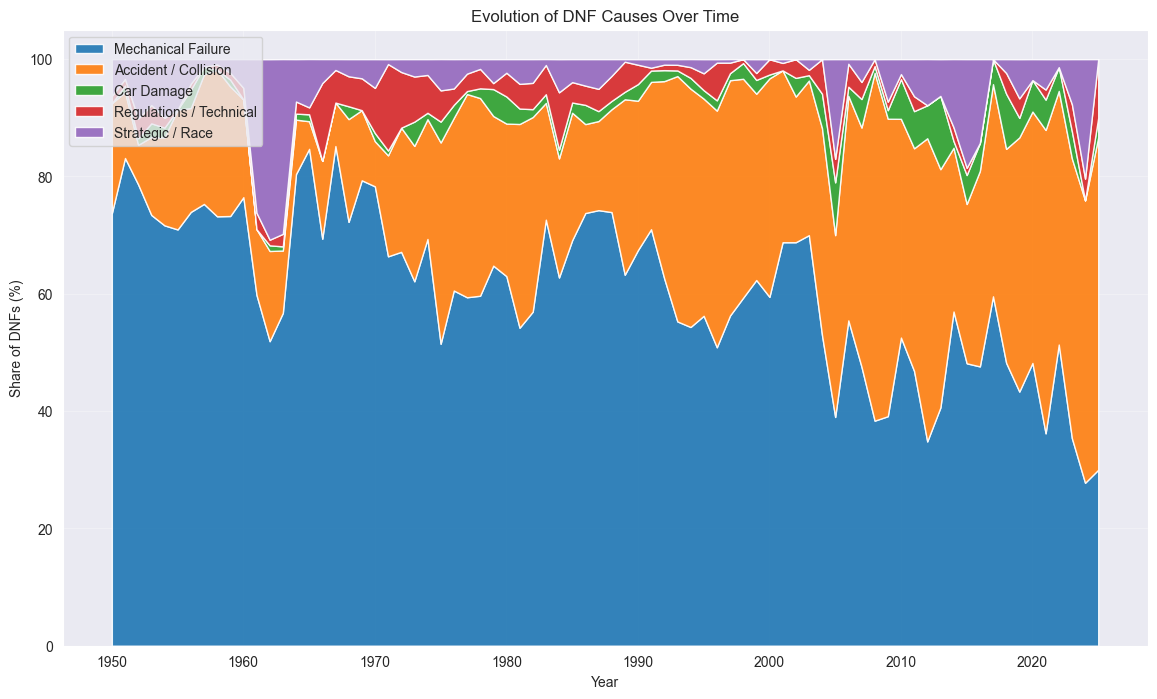

In [52]:
stacked_df = (
    dnf_status_by_year
    .pivot(index='year', columns='dnfStatus', values='percent')
    .fillna(0)
    .sort_index()
)

order = [
    'Mechanical Failure',
    'Accident / Collision',
    'Car Damage',
    'Regulations / Technical',
    'Strategic / Race',
    'Other'
]

order = [c for c in order if c in stacked_df.columns]

plt.figure(figsize=(14, 8))

plt.stackplot(
    stacked_df.index,
    [stacked_df[c] for c in order],
    labels=order,
    alpha=0.9
)

plt.title("Evolution of DNF Causes Over Time")
plt.xlabel("Year")
plt.ylabel("Share of DNFs (%)")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()


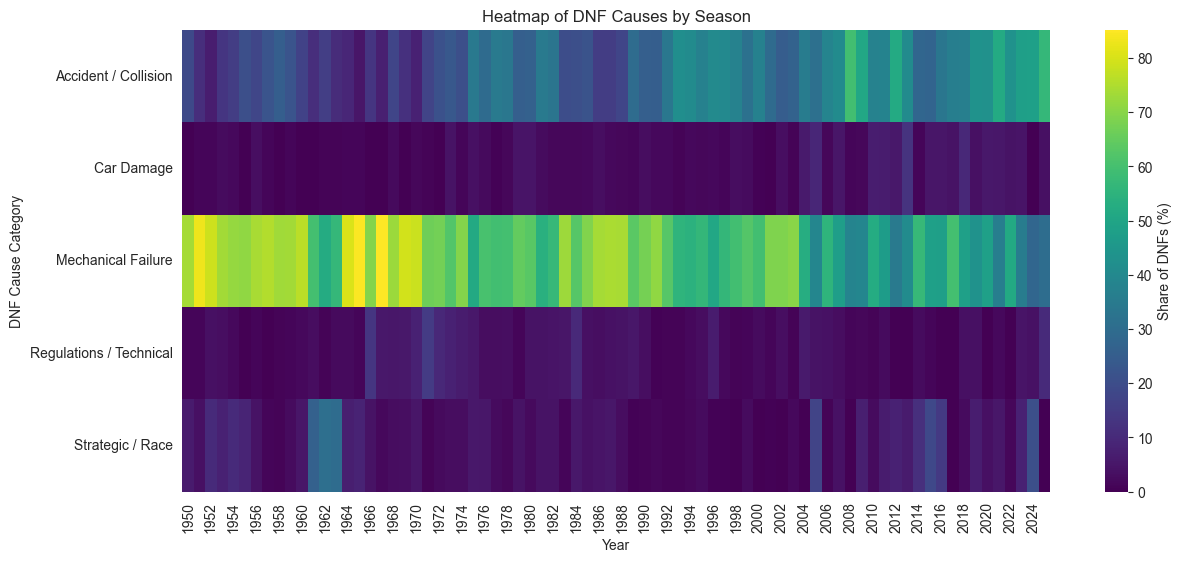

In [53]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    stacked_df.T,
    cmap='viridis',
    cbar_kws={'label': 'Share of DNFs (%)'}
)

plt.title("Heatmap of DNF Causes by Season")
plt.xlabel("Year")
plt.ylabel("DNF Cause Category")
plt.show()


### Evolution of DNF Causes Over Time

The analysis of aggregated DNF causes reveals a clear structural shift in the nature of race retirements across Formula 1 history.

In the early decades of Formula 1 (1950s–1970s), mechanical failures overwhelmingly dominated DNFs, accounting for roughly 70–85% of all retirements in most seasons. This reflects the limited reliability of early racing technology and the experimental nature of car design during that period.

From the 1980s onward, the relative share of mechanical failures gradually declined, while accident-related retirements became increasingly prominent. By the modern era (2000s–2020s), accidents and collisions account for a comparable — and in some seasons larger — share of DNFs than mechanical failures.

Other categories, such as car damage, regulatory or technical exclusions, and strategic or race-related retirements, remain consistently minor contributors throughout the entire history of Formula 1. While these factors occasionally spike in individual seasons, they do not represent dominant structural drivers of DNFs.

Overall, the results highlight a fundamental transition in Formula 1 reliability dynamics: from an era where cars primarily failed due to mechanical limitations to a modern era where retirements are more strongly influenced by racing incidents and on-track competition.

These findings complement the season-level DNF rate analysis, showing that improvements in overall reliability were driven primarily by reductions in mechanical failures rather than a decline in race incidents.


## Constructor Reliability in Modern Formula 1


This section focuses on constructor reliability in the modern Formula 1 era, defined here as seasons from 2010 onward.


In [99]:
df = results.merge(races[['raceId', 'year']], on='raceId', how='left')
df = df[df['year'] >= 2010]
df

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,statusGroup,year
20320,20323,337,4,6,8,3,1,1,1,25.0,49,1:39:20.396,5960396,45,1,1:58.287,191.706,1,Finished,2010
20321,20324,337,13,6,7,2,2,2,2,18.0,49,+16.099,5976495,38,5,1:59.732,189.392,1,Finished,2010
20322,20325,337,1,1,2,4,3,3,3,15.0,49,+23.182,5983578,42,4,1:59.560,189.665,1,Finished,2010
20323,20326,337,20,9,5,1,4,4,4,12.0,49,+38.799,5999195,32,12,2:00.218,188.627,1,Finished,2010
20324,20327,337,3,131,4,5,5,5,5,10.0,49,+40.213,6000609,45,13,2:00.236,188.599,1,Finished,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27233,27239,1168,848,3,23,17,16,16,16,0.0,58,+90.327,5257796,45,12,1:28.367,\N,1,Finished,2025
27234,27240,1168,865,215,6,9,17,17,17,0.0,57,\N,\N,52,20,1:29.375,\N,11,Finished,2025
27235,27241,1168,859,215,30,13,18,18,18,0.0,57,\N,\N,39,16,1:28.886,\N,11,Finished,2025
27236,27242,1168,842,214,10,19,19,19,19,0.0,57,\N,\N,46,8,1:27.767,\N,11,Finished,2025


In [100]:
constructors_status_in_modern_era = (
    df
    .merge(constructors[['constructorId', 'name']], on='constructorId', how='left')
    .groupby(['name', 'statusGroup'])
    .size()
    .reset_index(name='count')
)

constructors_status_in_modern_era

,name,statusGroup,count
0,Alfa Romeo,DNF,28
1,Alfa Romeo,Finished,180
2,AlphaTauri,DNF,27
3,AlphaTauri,Finished,139
4,Alpine F1 Team,DNF,35
5,Alpine F1 Team,Finished,193
6,Aston Martin,DNF,33
7,Aston Martin,Finished,194
8,Caterham,DNF,25
9,Caterham,Finished,87


Constructor names may change over time due to branding or ownership, while the underlying team infrastructure remains continuous.
To account for this, constructors representing the same team lineage (e.g. Toro Rosso → AlphaTauri → RB) are grouped together in the reliability analysis.


In [101]:
constructors_name_dict = {
    'Alpine F1 (Renault)': ['Alpine F1 Team', 'Lotus', 'Lotus F1', 'Renault'],
    'Alfa Romeo Sauber': ['Alfa Romeo', 'Sauber'],
    'RB': ['AlphaTauri', 'RB F1 Team', 'Toro Rosso'],
    'Marussia' : ['Marussia', 'Manor Marussia'],
    'Aston Martin' : ['Aston Martin', 'Racing Point'],
}

constructors_mapping = {
    old_name: new_name
    for new_name, old_names in constructors_name_dict.items()
    for old_name in old_names
}

constructors_status_in_modern_era['team_group'] = (
    constructors_status_in_modern_era['name']
    .map(constructors_mapping)
    .fillna(constructors_status_in_modern_era['name'])
)

constructors_status_in_modern_era

,name,statusGroup,count,team_group
0,Alfa Romeo,DNF,28,Alfa Romeo Sauber
1,Alfa Romeo,Finished,180,Alfa Romeo Sauber
2,AlphaTauri,DNF,27,RB
3,AlphaTauri,Finished,139,RB
4,Alpine F1 Team,DNF,35,Alpine F1 (Renault)
5,Alpine F1 Team,Finished,193,Alpine F1 (Renault)
6,Aston Martin,DNF,33,Aston Martin
7,Aston Martin,Finished,194,Aston Martin
8,Caterham,DNF,25,Caterham
9,Caterham,Finished,87,Caterham


In [102]:
constructors_status_grouped = (
    constructors_status_in_modern_era
    .groupby(['team_group', 'statusGroup'], as_index=False)['count']
    .sum()
)
constructors_status_grouped

,team_group,statusGroup,count
0,Alfa Romeo Sauber,DNF,132
1,Alfa Romeo Sauber,Finished,525
2,Alfa Romeo Sauber,NotFinishedNotDNF,1
3,Alpine F1 (Renault),DNF,168
4,Alpine F1 (Renault),Finished,566
5,Aston Martin,DNF,46
6,Aston Martin,Finished,257
7,Caterham,DNF,25
8,Caterham,Finished,87
9,Ferrari,DNF,83


In [103]:
constructors_status_grouped['total_starts'] = constructors_status_grouped.groupby('team_group')['count'].transform('sum')
constructors_status_grouped['percent'] = ((constructors_status_grouped['count'] / constructors_status_grouped['total_starts']) * 100).round(2)
constructors_status_grouped

,team_group,statusGroup,count,total_starts,percent
0,Alfa Romeo Sauber,DNF,132,658,20.06
1,Alfa Romeo Sauber,Finished,525,658,79.79
2,Alfa Romeo Sauber,NotFinishedNotDNF,1,658,0.15
3,Alpine F1 (Renault),DNF,168,734,22.89
4,Alpine F1 (Renault),Finished,566,734,77.11
5,Aston Martin,DNF,46,303,15.18
6,Aston Martin,Finished,257,303,84.82
7,Caterham,DNF,25,112,22.32
8,Caterham,Finished,87,112,77.68
9,Ferrari,DNF,83,658,12.61


In [104]:
colors_for_bar = {
    'Ferrari': '#DC0000',
    'McLaren': '#FF8700',
    'Red Bull': '#0600EF',
    'RB': '#1E3A8A',
    'Williams': '#00A3E0',
    'Mercedes': '#00D2BE',
    'Aston Martin': '#006F62',
    'Alpine F1 (Renault)': '#0090FF',
    'Alfa Romeo Sauber': '#900000',
    'Haas F1 Team': '#111111',
    'Force India': '#F596C8',
    'Caterham': '#00A651',
    'Marussia': '#6B3F2A',
    'Virgin': '#E4002B',
    'HRT': '#7A4E2D'
}




In [105]:
dnf_constructors_modern_era = constructors_status_grouped[constructors_status_grouped['statusGroup'] == 'DNF']
dnf_constructors_modern_era

,team_group,statusGroup,count,total_starts,percent
0,Alfa Romeo Sauber,DNF,132,658,20.06
3,Alpine F1 (Renault),DNF,168,734,22.89
5,Aston Martin,DNF,46,303,15.18
7,Caterham,DNF,25,112,22.32
9,Ferrari,DNF,83,658,12.61
11,Force India,DNF,61,354,17.23
14,HRT,DNF,32,116,27.59
17,Haas F1 Team,DNF,78,428,18.22
20,Marussia,DNF,29,187,15.51
22,McLaren,DNF,110,658,16.72


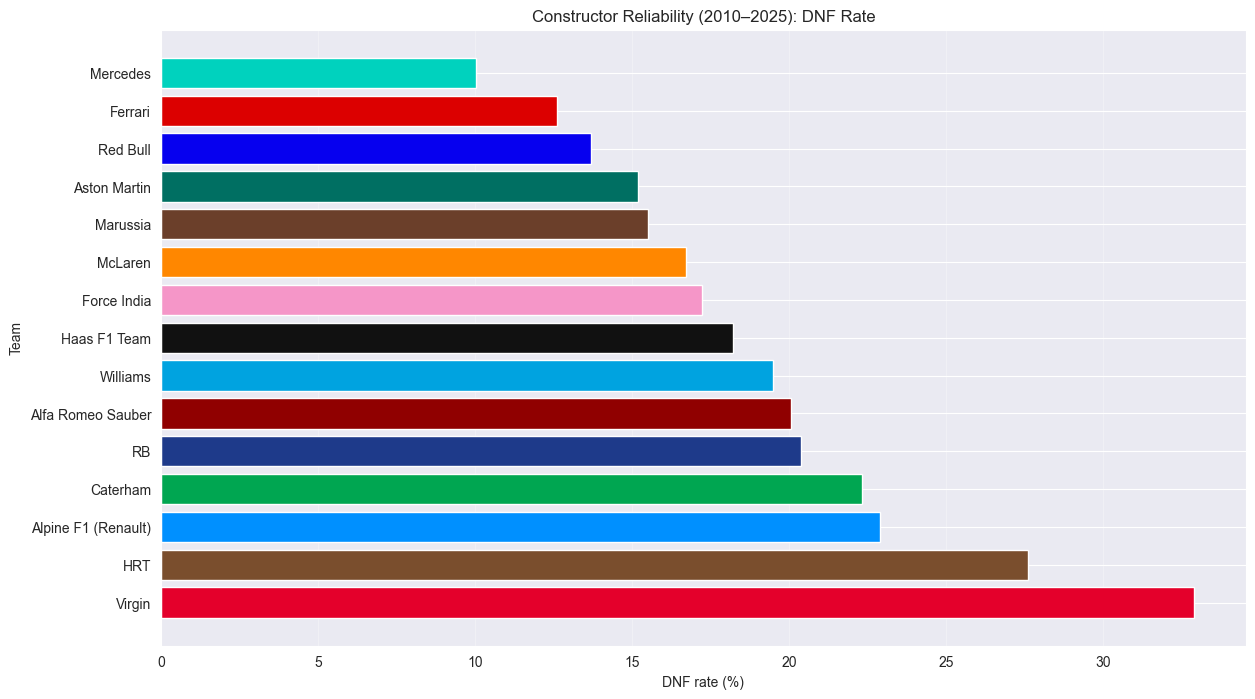

In [106]:
df_plot = dnf_constructors_modern_era.sort_values('percent')
bar_colors = [colors_for_bar.get(t, '#9CA3AF') for t in df_plot['team_group']]

plt.figure(figsize=(14, 8))
plt.barh(df_plot['team_group'], df_plot['percent'], color=bar_colors)

plt.xlabel("DNF rate (%)")
plt.ylabel("Team")
plt.title("Constructor Reliability (2010–2025): DNF Rate")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()


### Constructor Reliability in the Modern Era (2010–2025)

The chart compares Formula 1 constructors by their DNF rate in the modern era (2010–2025), providing a team-level perspective on reliability.

Clear differences emerge across teams. Leading constructors such as **Mercedes**, **Ferrari**, and **Red Bull** exhibit consistently lower DNF rates, reflecting a high level of technical maturity, operational stability, and resource availability.

Midfield teams show greater variability in reliability, while constructors with shorter lifespans or limited resources — such as **Caterham**, **HRT**, and **Virgin** — display substantially higher DNF rates. This highlights the strong relationship between organizational continuity, technical investment, and race reliability.

Overall, the results reinforce the idea that reliability is not only a technical attribute of individual cars, but also a structural characteristic of teams operating at different competitive and organizational levels.


## Engine Reliability in the Hybrid Era (2014–2025)


This section analyzes power unit reliability during the hybrid era of Formula 1 (2014–2025), a period defined by a stable V6 turbo-hybrid engine regulation.


In [209]:
results_of_hybrid_era = (
    results
    .merge(races[['raceId', 'year']], on='raceId', how='left')
)

In [210]:
results_of_hybrid_era = results_of_hybrid_era[results_of_hybrid_era['year'] >= 2014]
results_of_hybrid_era

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,statusGroup,year
22127,22130,900,3,131,6,3,1,1,1,25.0,57,1:32:58.710,5578710,19,1,1:32.478,206.436,1,Finished,2014
22128,22131,900,825,1,20,4,2,2,2,18.0,57,+26.777,5605487,49,6,1:33.066,205.131,1,Finished,2014
22129,22132,900,18,1,22,10,3,3,3,15.0,57,+30.027,5608737,39,5,1:32.917,205.46,1,Finished,2014
22130,22133,900,4,6,14,5,4,4,4,12.0,57,+35.284,5613994,57,7,1:33.186,204.867,1,Finished,2014
22131,22134,900,822,3,77,15,5,5,5,10.0,57,+47.639,5626349,56,3,1:32.616,206.128,1,Finished,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27233,27239,1168,848,3,23,17,16,16,16,0.0,58,+90.327,5257796,45,12,1:28.367,\N,1,Finished,2025
27234,27240,1168,865,215,6,9,17,17,17,0.0,57,\N,\N,52,20,1:29.375,\N,11,Finished,2025
27235,27241,1168,859,215,30,13,18,18,18,0.0,57,\N,\N,39,16,1:28.886,\N,11,Finished,2025
27236,27242,1168,842,214,10,19,19,19,19,0.0,57,\N,\N,46,8,1:27.767,\N,11,Finished,2025


In [211]:
seasons = load_data('seasons')

In [127]:
# import pandas as pd
# from features.parsers import parse_engines_for_years
# years = list(range(2014, 2026))
# engines = parse_engines_for_years(years)
#
# engines.head()

# from pathlib import Path
#
# out_path = Path("../data/processed/engine_lookup_hybrid_era.csv")
# out_path.parent.mkdir(parents=True, exist_ok=True)
#
# engines.to_csv(out_path, index=False)

#

Parsing 2014...
Parsing 2015...
Parsing 2016...
Parsing 2017...
Parsing 2018...
Rate limited (403). Sleep 11.7s (attempt 1/5)
Rate limited (403). Sleep 20.6s (attempt 2/5)
Rate limited (403). Sleep 30.6s (attempt 3/5)
Rate limited (403). Sleep 41.3s (attempt 4/5)
Rate limited (403). Sleep 50.6s (attempt 5/5)
Parsing 2019...
Parsing 2020...
Parsing 2021...
Parsing 2022...
Parsing 2023...
Parsing 2024...
Parsing 2025...


,year,constructor_wiki,power_unit_raw,engine_mfr
0,2014,Caterham - Renault,Renault Energy F1-2014,Renault
1,2014,Ferrari,Ferrari 059/3,Ferrari
2,2014,Force India - Mercedes,Mercedes PU106A Hybrid,Mercedes
3,2014,Lotus - Renault,Renault Energy F1-2014,Renault
4,2014,Marussia - Ferrari,Ferrari 059/3,Ferrari


In [197]:
ENGINE_DNF_IDS_STRICT = [
    5,    # Engine
    56,   # Engine fire
    129,  # Engine misfire
    131,  # Power Unit
    132,  # ERS
    101,  # Turbo
    25,   # Overheating
    141   # Cooling system
]

engine_trouble = results_of_hybrid_era[
    results_of_hybrid_era['statusId'].isin(ENGINE_DNF_IDS_STRICT)
]
engine_trouble

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,statusGroup,year
22141,22144,900,154,208,8,22,\N,R,15,0.0,43,\N,\N,41,15,1:35.281,200.363,132,DNF,2014
22142,22145,900,813,208,13,21,\N,R,16,0.0,29,\N,\N,30,14,1:34.766,201.451,132,DNF,2014
22144,22147,900,20,9,1,12,\N,R,18,0.0,3,\N,\N,26,17,1:37.064,196.682,5,DNF,2014
22145,22148,900,1,131,44,1,\N,R,19,0.0,2,\N,\N,2,20,1:49.947,173.636,5,DNF,2014
22167,22170,901,818,5,25,9,\N,R,19,0.0,18,\N,\N,4,19,1:48.527,183.869,131,DNF,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26917,26923,1152,4,117,14,6,19,R,19,0.0,36,\N,\N,15,18,1:15.593,\N,5,DNF,2025
26936,26942,1153,863,131,12,6,18,R,18,0.0,53,\N,\N,52,12,1:18.255,\N,5,DNF,2025
26956,26962,1154,859,215,30,19,19,R,19,0.0,53,\N,\N,52,20,1:16.320,\N,25,DNF,2025
26957,26963,1154,848,3,23,9,20,R,20,0.0,46,\N,\N,31,18,1:16.197,\N,5,DNF,2025


In [214]:
engines = pd.read_csv("../data/processed/engine_lookup_hybrid_era.csv")
engines

,year,constructor_wiki,power_unit_raw,engine_mfr
0,2014,Caterham - Renault,Renault Energy F1-2014,Renault
1,2014,Ferrari,Ferrari 059/3,Ferrari
2,2014,Force India - Mercedes,Mercedes PU106A Hybrid,Mercedes
3,2014,Lotus - Renault,Renault Energy F1-2014,Renault
4,2014,Marussia - Ferrari,Ferrari 059/3,Ferrari
...,...,...,...,...
107,2025,McLaren - Mercedes,Mercedes-AMG F1 M16,Mercedes
108,2025,Mercedes,Mercedes-AMG F1 M16,Mercedes
109,2025,Racing Bulls - Honda RBPT,Honda RBPTH003,Honda
110,2025,Red Bull Racing - Honda RBPT,Honda RBPTH003,Honda


      engine_mfr  entries  engine_dnfs  engine_dnf_rate
2       Mercedes     1574           25             1.59
0        Ferrari      529           10             1.89
3  Other/Unknown      126            4             3.17
1          Honda      428           19             4.44
4        Renault      186           10             5.38


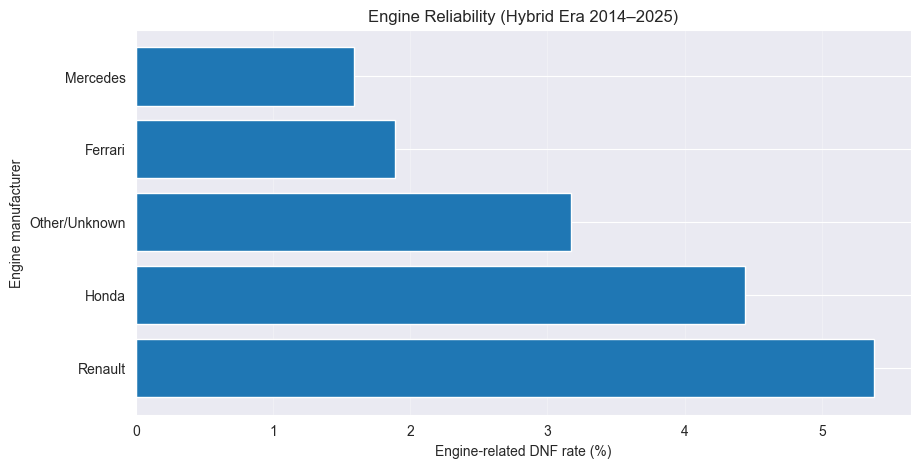

In [215]:
# ===== Block E: Engine Reliability (Hybrid Era 2014–2025) =====
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) SETTINGS
# -----------------------------
ENGINE_DNF_IDS_STRICT = [5, 56, 129, 131, 132, 101, 25, 141]  # Engine / PU / ERS / Turbo / Overheating / Cooling

START_YEAR = 2014
END_YEAR = 2025  # inclusive

# EXPECTED INPUT DATAFRAMES:
# results: Ergast results.csv loaded
# races:   races.csv loaded (must contain raceId, year)
# constructors: constructors.csv loaded (must contain constructorId, name)
# engines: loaded from your CSV (must contain year, constructor_wiki, engine_mfr)

# -----------------------------
# 1) MAKE team_group IN constructors (use your dict)
# -----------------------------
# You already have this dict; keep it as-is and extend if needed.
constructors_name_dict = {
    'Alpine F1 (Renault)': ['Alpine F1 Team', 'Lotus', 'Lotus F1', 'Renault'],
    'Alfa Romeo Sauber': ['Alfa Romeo', 'Sauber'],
    'RB': ['AlphaTauri', 'RB F1 Team', 'Toro Rosso'],
    'Marussia': ['Marussia', 'Manor Marussia'],
    'Aston Martin': ['Aston Martin', 'Racing Point'],
}

team_group_map = {old: group for group, olds in constructors_name_dict.items() for old in olds}

constructors = constructors.copy()
constructors["team_group"] = constructors["name"].map(team_group_map).fillna(constructors["name"])

# -----------------------------
# 2) CLEAN + MATCH WIKI CONSTRUCTOR NAMES TO OUR team_group
# -----------------------------
engines = engines.copy()
engines = engines[["year", "constructor_wiki", "engine_mfr"]]

# remove engine suffix after " - " and normalize spaces
engines["constructor_clean"] = (
    engines["constructor_wiki"]
    .astype(str)
    .str.split(" - ", n=1)
    .str[0]
    .str.replace("\xa0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# canonical list: use our team_group values (most stable), longer-first
canonical_names = sorted(constructors["team_group"].dropna().unique().tolist(), key=len, reverse=True)

def match_to_canonical(wiki_name: str, canonical_list: list[str]) -> str | None:
    if pd.isna(wiki_name):
        return None
    s = str(wiki_name).lower()
    for cname in canonical_list:
        if cname.lower() in s:
            return cname
    return None

engines["team_group"] = engines["constructor_clean"].apply(lambda x: match_to_canonical(x, canonical_names))

# If you have a few misses, handle them here (edit as needed)
manual_fixes = {
    # "Williams Martini Racing": "Williams",
    # "Lotus F1 Team": "Alpine F1 (Renault)",
}
engines["team_group"] = engines["team_group"].fillna(engines["constructor_clean"].map(manual_fixes))

# Keep only mapped rows
engine_lookup = engines.dropna(subset=["team_group"]).drop_duplicates(subset=["year", "team_group", "engine_mfr"])

# -----------------------------
# 3) BUILD HYBRID RESULTS WITH team_group + engine_mfr
# -----------------------------
hybrid_results = (
    results
    .merge(races[["raceId", "year"]], on="raceId", how="left")
)

hybrid_results = hybrid_results[(hybrid_results["year"] >= START_YEAR) & (hybrid_results["year"] <= END_YEAR)]

# add team_group via constructorId
hybrid_results = hybrid_results.merge(
    constructors[["constructorId", "team_group"]],
    on="constructorId",
    how="left"
)

# add engine_mfr via (year, team_group)
hybrid_results = hybrid_results.merge(
    engine_lookup[["year", "team_group", "engine_mfr"]],
    on=["year", "team_group"],
    how="left"
)

# -----------------------------
# 4) ENTRIES BY ENGINE (DENOMINATOR)
# -----------------------------
entries_by_engine = (
    hybrid_results
    .dropna(subset=["engine_mfr"])
    .groupby("engine_mfr")
    .size()
    .reset_index(name="entries")
)

# -----------------------------
# 5) ENGINE-RELATED DNFS BY ENGINE (NUMERATOR)
# -----------------------------
engine_dnfs = hybrid_results[
    hybrid_results["statusId"].isin(ENGINE_DNF_IDS_STRICT)
].copy()

engine_dnfs_by_engine = (
    engine_dnfs
    .dropna(subset=["engine_mfr"])
    .groupby("engine_mfr")
    .size()
    .reset_index(name="engine_dnfs")
)

# -----------------------------
# 6) FINAL TABLE + RATE
# -----------------------------
engine_reliability = (
    entries_by_engine
    .merge(engine_dnfs_by_engine, on="engine_mfr", how="left")
    .fillna({"engine_dnfs": 0})
)

engine_reliability["engine_dnfs"] = engine_reliability["engine_dnfs"].astype(int)
engine_reliability["engine_dnf_rate"] = (engine_reliability["engine_dnfs"] / engine_reliability["entries"] * 100).round(2)
engine_reliability = engine_reliability.sort_values("engine_dnf_rate", ascending=True)

print(engine_reliability)

# -----------------------------
# 7) PLOT (HORIZONTAL BAR)
# -----------------------------
plt.figure(figsize=(10, 5))
plt.barh(engine_reliability["engine_mfr"], engine_reliability["engine_dnf_rate"])
plt.xlabel("Engine-related DNF rate (%)")
plt.ylabel("Engine manufacturer")
plt.title(f"Engine Reliability (Hybrid Era {START_YEAR}–{END_YEAR})")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

# -----------------------------
# 8) OPTIONAL: SAVE OUTPUTS
# -----------------------------
# engine_reliability.to_csv("../data/processed/engine_reliability_hybrid_era.csv", index=False)

# Debug helpers (use if needed):
# print("Unmatched wiki constructors (sample):")
# print(engines[engines["team_group"].isna()][["year","constructor_wiki","constructor_clean"]].drop_duplicates().head(30))
# print("Missing engine_mfr after merge (sample):")
# print(hybrid_results[hybrid_results["engine_mfr"].isna()][["year","team_group","constructorId"]].drop_duplicates().head(30))


This figure summarizes engine reliability over the entire hybrid era (2014–2025) using
the engine-related DNF rate. Mercedes engines exhibit the strongest overall reliability,
while Renault and Honda show higher failure rates, largely driven by issues in the early
years of hybrid power unit development.


In [219]:
engine_dnfs_by_year = (
    engine_dnfs
    .groupby(['year', 'engine_mfr'])
    .size()
    .reset_index(name='dnf_count')
    .sort_values('year')
)

engine_dnfs_by_year

,year,engine_mfr,dnf_count
0,2014,Ferrari,1
1,2014,Mercedes,3
2,2014,Renault,5
3,2015,Ferrari,1
4,2015,Honda,4
5,2015,Mercedes,1
6,2015,Renault,2
7,2016,Ferrari,2
8,2016,Honda,3
9,2016,Mercedes,3


In [217]:
engine_colors = {
    'Mercedes': '#00D2BE',
    'Ferrari': '#DC0000',
    'Renault': '#FFD800',
    'Honda': '#E6002D',
    'Other/Unknown': 'gray'
}


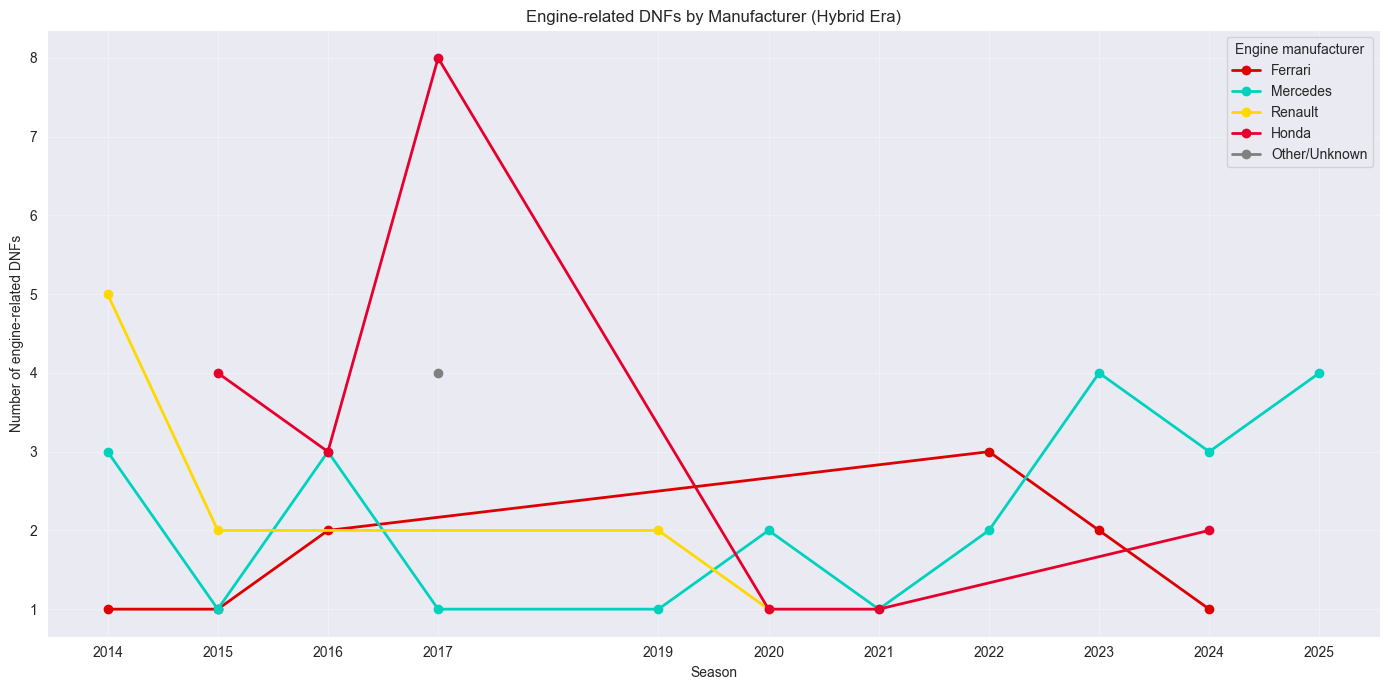

In [218]:
plt.figure(figsize=(14, 7))

for engine in engine_dnfs_by_year['engine_mfr'].unique():
    sub = engine_dnfs_by_year[engine_dnfs_by_year['engine_mfr'] == engine]

    plt.plot(
        sub['year'],
        sub['dnf_count'],
        marker='o',
        linewidth=2,
        label=engine,
        color=engine_colors.get(engine, 'black')
    )

plt.title("Engine-related DNFs by Manufacturer (Hybrid Era)")
plt.xlabel("Season")
plt.ylabel("Number of engine-related DNFs")
plt.xticks(sorted(engine_dnfs_by_year['year'].unique()))
plt.grid(True, alpha=0.3)
plt.legend(title="Engine manufacturer")
plt.tight_layout()
plt.show()


The chart illustrates the number of engine-related retirements per season for each power unit manufacturer
during the hybrid era. Early years show significantly higher failure counts for Honda and Renault, while
Mercedes demonstrates consistently strong reliability across seasons. Over time, the gap between manufacturers
narrows, reflecting overall improvements in hybrid power unit reliability.
